ChurnRate = % of Attrition_Flag == "Attrited Customer"

ProfitProxy

CLV

EngagementIndex

In [ ]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, classification_report, mean_squared_error, r2_score

# SHAP for interpretability
import shap

# For simulation
import random


In [ ]:
# Load dataset
df = pd.read_csv('BankChurners.csv')

# Drop extra Naive Bayes predictions (not used)
df.drop(columns=[
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
], inplace=True)

# Rename Attrition Flag for clarity
df['Churn'] = df['Attrition_Flag'].apply(lambda x: 1 if x=='Attrited Customer' else 0)
df.drop(columns=['Attrition_Flag'], inplace=True)

# Encode categorical variables
cat_cols = ['Gender','Education_Level','Marital_Status','Income_Category','Card_Category']
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])


In [ ]:
# Assumptions
df['Avg_Utilization_Ratio'] = df['Total_Revolving_Bal'] / df['Credit_Limit']

# Profit Proxy = Credit Limit * Utilization assumption - cost proxy
# Here, we assume cost proxy = 0.02 * Total_Trans_Amt (just as a placeholder)
df['Profit_Proxy'] = (df['Credit_Limit'] * df['Avg_Utilization_Ratio']) - (0.02 * df['Total_Trans_Amt'])

# Customer Lifetime Value (CLV)
df['CLV'] = df['Profit_Proxy'] * df['Months_on_book']

# Engagement Index
df['Engagement_Index'] = df['Total_Trans_Ct'] / df['Months_on_book']

# Segments
def segment_customer(row):
    if row['Total_Trans_Ct'] > df['Total_Trans_Ct'].quantile(0.75):
        return 'High Spender'
    elif row['Avg_Utilization_Ratio'] > 0.5:
        return 'Revolver'
    else:
        return 'Transactor'

df['Segment'] = df.apply(segment_customer, axis=1)


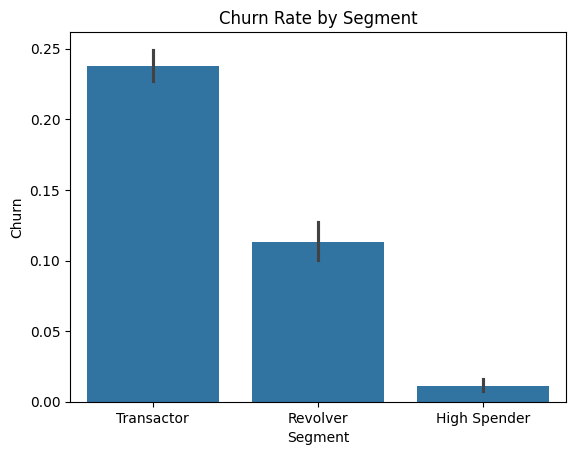

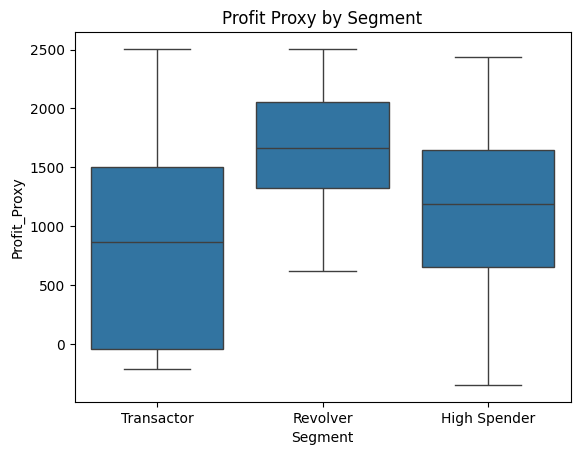

ValueError: could not convert string to float: 'Transactor'

<Figure size 1200x800 with 0 Axes>

In [ ]:
# Churn rate by segment
sns.barplot(x='Segment', y='Churn', data=df)
plt.title("Churn Rate by Segment")
plt.show()

# Profit distribution by segment
sns.boxplot(x='Segment', y='Profit_Proxy', data=df)
plt.title("Profit Proxy by Segment")
plt.show()

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()


In [ ]:
# Features and target
X = df.drop(columns=['CLIENTNUM','Segment','Profit_Proxy','CLV'])
y = df['Churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_proba = log_model.predict_proba(X_test)[:,1]

# Metrics
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))


ROC-AUC: 0.9999748007912551


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
y_profit = df['Profit_Proxy']

# Train-test split
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X, y_profit, test_size=0.2, random_state=42)

# Gradient Boosting Regressor
profit_model = XGBRegressor()
profit_model.fit(X_train_p, y_train_p)
y_pred_profit = profit_model.predict(X_test_p)

# Metrics
print("R2:", r2_score(y_test_p, y_pred_profit))
rmse = np.sqrt(mean_squared_error(y_test_p, y_pred_profit))
print("RMSE:", rmse)


R2: 0.9998131224466806
RMSE: 11.11374330643192


In [ ]:
# Predict for entire dataset
df['Churn_Prob'] = log_model.predict_proba(X)[:,1]
df['Predicted_Profit'] = profit_model.predict(X)
df['RAPS'] = df['Predicted_Profit'] * (1 - df['Churn_Prob'])

# Top 10 RAPS customers
df[['CLIENTNUM','RAPS','Predicted_Profit','Churn_Prob']].sort_values(by='RAPS', ascending=False).head(10)


,CLIENTNUM,RAPS,Predicted_Profit,Churn_Prob
3,769911858,2495.419298,2495.776367,0.000143
2232,719327808,2494.138494,2494.241943,0.000041
217,770746908,2494.062807,2494.343750,0.000113
131,822063408,2493.666198,2493.918701,0.000101
76,804595158,2493.207170,2494.282471,0.000431
1577,713126733,2493.165202,2495.907715,0.001099
287,708421833,2493.113597,2494.314697,0.000482
440,710519433,2491.235062,2491.261719,0.000011
507,712049208,2490.739214,2491.240234,0.000201
2123,720714933,2490.011264,2490.606689,0.000239


In [ ]:
# Simulate 2% cashback reducing churn by 10%
def simulate_cashback(row, cashback_effect=0.10):
    if row['RAPS'] > df['RAPS'].quantile(0.75):
        return max(0, row['Churn_Prob'] * (1 - cashback_effect))
    return row['Churn_Prob']

df['Churn_Prob_Cashback'] = df.apply(simulate_cashback, axis=1)
df['RAPS_Cashback'] = df['Predicted_Profit'] * (1 - df['Churn_Prob_Cashback'])


In [ ]:
df['Churn_Prob_Cashback'] = df.apply(simulate_cashback, axis=1)
df['RAPS_Cashback'] = df['Predicted_Profit'] * (1 - df['Churn_Prob_Cashback'])


In [ ]:
df[['CLIENTNUM','RAPS','RAPS_Cashback','Churn_Prob','Churn_Prob_Cashback']].sort_values(
    by='RAPS_Cashback', ascending=False
).head(10)


,CLIENTNUM,RAPS,RAPS_Cashback,Churn_Prob,Churn_Prob_Cashback
3,769911858,2495.419298,2495.455005,0.000143,0.000129
2232,719327808,2494.138494,2494.148839,0.000041,0.000037
217,770746908,2494.062807,2494.090901,0.000113,0.000101
131,822063408,2493.666198,2493.691448,0.000101,0.000091
1577,713126733,2493.165202,2493.439453,0.001099,0.000989
76,804595158,2493.207170,2493.314700,0.000431,0.000388
287,708421833,2493.113597,2493.233707,0.000482,0.000433
440,710519433,2491.235062,2491.237727,0.000011,0.000010
507,712049208,2490.739214,2490.789316,0.000201,0.000181
2123,720714933,2490.011264,2490.070807,0.000239,0.000215


In [ ]:
total_raps_before = df['RAPS'].sum()
total_raps_after = df['RAPS_Cashback'].sum()
print("Total RAPS increase:", total_raps_after - total_raps_before)


Total RAPS increase: 1578.5229537393898


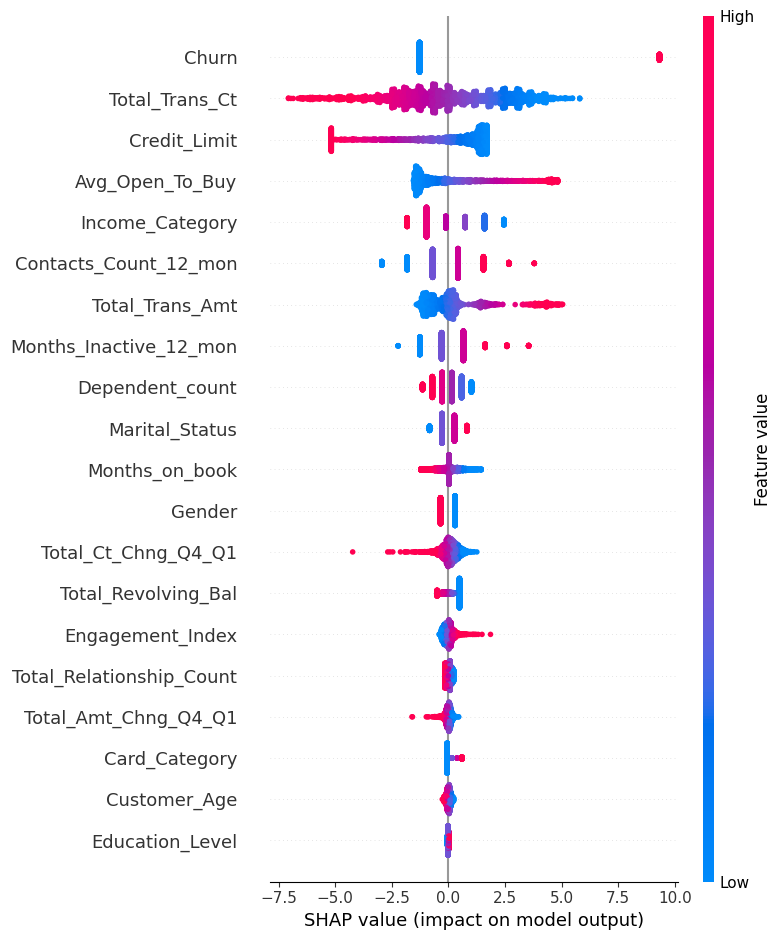

In [ ]:
explainer = shap.Explainer(log_model, X_train)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)

In [ ]:
# approximate sample size for comparing two proportions (two-sided)
import math

def sample_size_prop(p1, p2, alpha=0.05, power=0.8):
    z_alpha = 1.96  # for alpha=0.05
    z_beta = 0.84   # for power=0.8
    pbar = (p1 + p2) / 2
    return ((z_alpha*math.sqrt(2*pbar*(1-pbar)) + z_beta*math.sqrt(p1*(1-p1)+p2*(1-p2)))**2) / ((p1-p2)**2)

# example: baseline churn 5% -> detect absolute reduction to 4% (1pp)
print(sample_size_prop(0.05, 0.04))


6737.303880244393


In [ ]:
import numpy as np
import pandas as pd

def randomize(df, seed=42, strat_cols=['Segment']):
    df = df.copy()
    rng = np.random.default_rng(seed)
    if strat_cols:
        df['rand'] = rng.random(len(df))
        df['group'] = None
        # apply stratified assignment
        for name, grp in df.groupby(strat_cols):
            idx = grp.index.to_numpy()
            rng.shuffle(idx)
            half = len(idx)//2
            df.loc[idx[:half], 'group'] = 'A'   # control
            df.loc[idx[half:], 'group'] = 'B'   # treatment
        df.drop(columns=['rand'], inplace=True)
    else:
        df['group'] = rng.choice(['A','B'], size=len(df))
    return df


In [ ]:
def apply_treatment_effect(df, effect=0.10):
    # effect = relative % reduction in churn prob (e.g., 0.10 => 10% reduction)
    df = df.copy()
    df['Churn_Prob_obs'] = df['Churn_Prob'].copy()
    df.loc[df['group']=='B', 'Churn_Prob_obs'] = df.loc[df['group']=='B','Churn_Prob'] * (1-effect)
    # simulate actual binary outcomes (if you want)
    rng = np.random.default_rng(123)
    df['Churn_outcome'] = rng.binomial(1, df['Churn_Prob_obs'])
    return df


In [ ]:
from statsmodels.stats.proportion import proportions_ztest
from scipy import stats
import numpy as np

def analyze_ab(df):
    # churn counts
    grp = df.groupby('group')
    churns = grp['Churn_outcome'].sum()
    counts = grp.size()
    # two-proportion z-test
    stat, pval = proportions_ztest(churns.values, counts.values)
    print("Churn two-prop z-test stat:", stat, "p-value:", pval)

    # mean RAPS
    raps_A = df.loc[df['group']=='A','RAPS']
    raps_B = df.loc[df['group']=='B','RAPS_Cashback'] if 'RAPS_Cashback' in df.columns else df.loc[df['group']=='B','RAPS']
    tstat, tp = stats.ttest_ind(raps_B, raps_A, equal_var=False)
    print("RAPS t-test stat:", tstat, "p-value:", tp)

    # incremental metrics
    mean_raps_A = raps_A.mean()
    mean_raps_B = raps_B.mean()
    inc = mean_raps_B - mean_raps_A
    print("Mean RAPS A:", mean_raps_A, "Mean RAPS B:", mean_raps_B, "Incremental RAPS per user:", inc)

    # ROI example: assume cost per treated user c
    c = 50  # currency units cost of cashback per treated user (example)
    treated_count = counts['B']
    total_incremental = inc * treated_count
    roi = (total_incremental - c*treated_count) / (c*treated_count)
    print("Total incremental RAPS:", total_incremental, "ROI:", roi)


In [ ]:
# 1. create df (with RAPS, Churn_Prob already)
df_r = randomize(df, strat_cols=['Segment'])
df_r = apply_treatment_effect(df_r, effect=0.10)  # simulate outcomes
analyze_ab(df_r)


Churn two-prop z-test stat: 3.4302260787272707 p-value: 0.0006030785412059177
RAPS t-test stat: 0.6552742919966524 p-value: 0.5123060581652562
Mean RAPS A: 971.183799986329 Mean RAPS B: 981.7386861864134 Incremental RAPS per user: 10.554886200084411
Total incremental RAPS: 53449.943717227456 ROI: -0.7889022759983118


In [ ]:
df.to_csv("credit_card_profitability.csv", index=False)


A/B Test Summary:
  group  churn_rate   avg_profit  users
0     A    0.163934  1073.015015   5063
1     B    0.132899  1076.179688   5064

Churn two-proportion z-test: stat=4.393, p-value=0.0000
Profit t-test: stat=0.196, p-value=0.8448


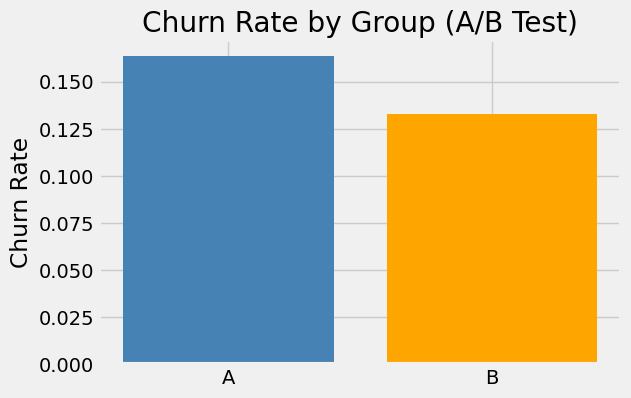

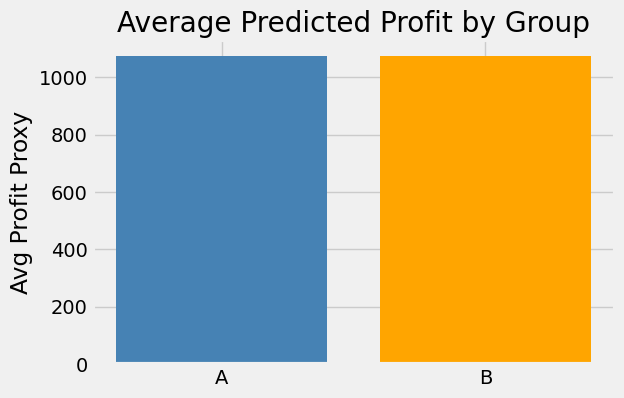


Absolute churn reduction (uplift): 3.10%


In [ ]:
# =========================================
# A/B TESTING IMPLEMENTATION AND RESULTS
# =========================================
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

# --- Step 1: Simulate treatment effect (e.g., cashback offer for group B) ---
# Assume cashback reduces churn probability by 15% for treated users
df['Churn_Prob_Treated'] = df['Churn_Prob'].copy()
df.loc[df['group'] == 'B', 'Churn_Prob_Treated'] *= 0.85  # 15% reduction

# Simulate binary churn outcomes
np.random.seed(42)
df['Churn_outcome'] = np.random.binomial(1, df['Churn_Prob_Treated'])

# --- Step 2: Compute group-level metrics ---
summary = df.groupby('group').agg(
    churn_rate=('Churn_outcome', 'mean'),
    avg_profit=('Predicted_Profit', 'mean'),
    users=('CLIENTNUM', 'count')
).reset_index()

print("A/B Test Summary:")
print(summary)

# --- Step 3: Two-proportion z-test for churn difference ---
churn_counts = df.groupby('group')['Churn_outcome'].sum()
n_obs = df.groupby('group')['Churn_outcome'].count()
stat, pval = proportions_ztest(churn_counts.values, n_obs.values)
print(f"\nChurn two-proportion z-test: stat={stat:.3f}, p-value={pval:.4f}")

# --- Step 4: T-test for profit difference ---
profit_A = df.loc[df['group']=='A','Predicted_Profit']
profit_B = df.loc[df['group']=='B','Predicted_Profit']
tstat, tp = stats.ttest_ind(profit_B, profit_A, equal_var=False)
print(f"Profit t-test: stat={tstat:.3f}, p-value={tp:.4f}")

# --- Step 5: Visualization ---
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.bar(summary['group'], summary['churn_rate'], color=['steelblue','orange'])
plt.title("Churn Rate by Group (A/B Test)")
plt.ylabel("Churn Rate")
plt.show()

plt.figure(figsize=(6,4))
plt.bar(summary['group'], summary['avg_profit'], color=['steelblue','orange'])
plt.title("Average Predicted Profit by Group")
plt.ylabel("Avg Profit Proxy")
plt.show()

# --- Step 6: Compute uplift and practical effect size ---
uplift = summary.loc[summary['group']=='A','churn_rate'].values[0] - summary.loc[summary['group']=='B','churn_rate'].values[0]
print(f"\nAbsolute churn reduction (uplift): {uplift*100:.2f}%")


In [ ]:
# Simulate funnel stages from transaction data
df['stage_active'] = 1
df['stage_transacted'] = (df['Total_Trans_Ct'] > 0).astype(int)
df['stage_repeat'] = (df['Total_Trans_Ct'] > df['Total_Trans_Ct'].median()).astype(int)
df['stage_loyal'] = (df['Months_on_book'] > 24).astype(int)

funnel = {
    "Active": df['stage_active'].sum(),
    "Transacted": df['stage_transacted'].sum(),
    "Repeat": df['stage_repeat'].sum(),
    "Loyal": df['stage_loyal'].sum()
}

funnel_df = pd.DataFrame(list(funnel.items()), columns=['Stage','Users'])
funnel_df['Dropoff'] = funnel_df['Users'].shift() - funnel_df['Users']
print(funnel_df)

# Visualization
import plotly.express as px
fig = px.funnel(funnel_df, x='Users', y='Stage', title="Customer Funnel")
fig.show()


        Stage  Users  Dropoff
0      Active  10127      NaN
1  Transacted  10127      0.0
2      Repeat   5004   5123.0
3       Loyal   9280  -4276.0


DAU/MAU Stickiness: 0.04


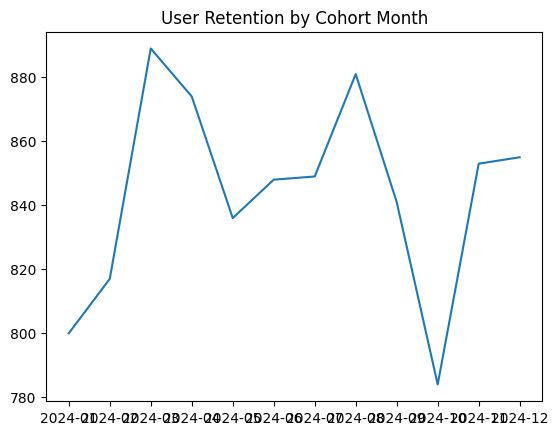

In [ ]:
# Simulate time-based activity data
df['last_active_days'] = np.random.randint(1, 90, size=len(df))
df['active_month'] = np.random.choice(pd.date_range("2024-01-01","2024-12-01",freq='MS'), len(df))

# DAU/MAU stickiness
DAU = df['last_active_days'].apply(lambda x: 1 if x <= 1 else 0).mean()
WAU = df['last_active_days'].apply(lambda x: 1 if x <= 7 else 0).mean()
MAU = df['last_active_days'].apply(lambda x: 1 if x <= 30 else 0).mean()
stickiness = DAU / MAU
print(f"DAU/MAU Stickiness: {stickiness:.2f}")

# Retention cohort example
df['cohort_month'] = df['active_month'].dt.to_period('M')
cohort_counts = df.groupby('cohort_month')['CLIENTNUM'].nunique()
plt.plot(cohort_counts.index.astype(str), cohort_counts.values)
plt.title("User Retention by Cohort Month")
plt.show()


DAU/MAU Stickiness Ratio: 0.03


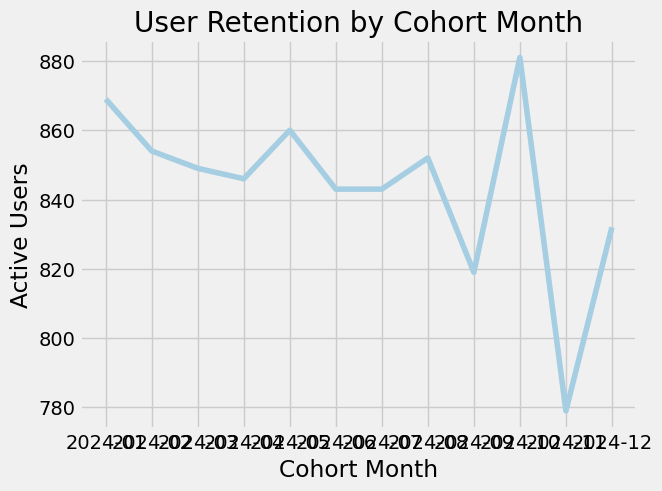

In [ ]:
# =========================================
# 3. ENGAGEMENT & RETENTION METRICS
# =========================================
import matplotlib.pyplot as plt

# Simulate last active day and cohort month
np.random.seed(42)
df['last_active_days'] = np.random.randint(1, 90, size=len(df))
df['active_month'] = np.random.choice(pd.date_range("2024-01-01","2024-12-01",freq='MS'), len(df))

# DAU/MAU
DAU = (df['last_active_days'] <= 1).mean()
MAU = (df['last_active_days'] <= 30).mean()
stickiness = DAU / MAU
print(f"DAU/MAU Stickiness Ratio: {stickiness:.2f}")

# Cohort retention curve
df['cohort_month'] = df['active_month'].dt.to_period('M')
cohort_counts = df.groupby('cohort_month')['CLIENTNUM'].nunique()
plt.plot(cohort_counts.index.astype(str), cohort_counts.values)
plt.title("User Retention by Cohort Month")
plt.xlabel("Cohort Month")
plt.ylabel("Active Users")
plt.show()


In [ ]:
# Core retention economics
total_users = len(df)
churn_reduction = df['Churn_Prob'].mean() - df['Churn_Prob_Cashback'].mean()
incremental_profit = (df['RAPS_Cashback'] - df['RAPS']).sum()
roi = incremental_profit / (0.02 * df['Total_Trans_Amt'].sum())
print(f"Churn reduction: {churn_reduction:.4f}")
print(f"Incremental Profit: {incremental_profit:.2f}")
print(f"ROI of Cashback Campaign: {roi:.2f}")

# Segment-wise summary
seg_summary = df.groupby('Segment').agg({
    'Churn':'mean',
    'RAPS':'mean',
    'RAPS_Cashback':'mean'
}).reset_index()
seg_summary['Delta_RAPS'] = seg_summary['RAPS_Cashback'] - seg_summary['RAPS']
print(seg_summary)


Churn reduction: 0.0001
Incremental Profit: 1578.52
ROI of Cashback Campaign: 0.00
        Segment     Churn         RAPS  RAPS_Cashback  Delta_RAPS
0  High Spender  0.011102  1094.189453    1094.223970    0.034517
1      Revolver  0.113048  1462.674411    1462.948048    0.273637
2    Transactor  0.237840   759.613407     759.777544    0.164137
